# Investment universe research

Strategy-research walkthrough for someone.

Use Orion's **whitelisted investment universe** and `PriceAdapterRegistry.price_history` to:

1. Pull daily point-in-time oracle prices;
2. Build an **excess return** panel (asset return minus protocol risk-free rate);
3. Inspect distributions, covariance / correlation, PCA, and a skfolio mean-risk portfolio.

Docs: https://sdk.orionfinance.ai/ · skfolio: https://skfolio.org/

## 0. Install

```bash
uv pip install orion-finance-sdk-py
uv pip install pandas matplotlib skfolio
```

Set a dedicated `RPC_URL` in `.env` (Alchemy/Infura). Public RPCs are rate-limited, universe history is many `eth_call`s per day.

In [1]:
from __future__ import annotations

import os
from datetime import datetime, timedelta, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from orion_finance_sdk_py import OrionConfig, PriceAdapterRegistry

load_dotenv()

# Orion brand-ish plot colors
BLUE = "#0D3AA9"
NAVY = "#051743"
MUTED = "#5c5c63"

LOOKBACK_DAYS = int(os.getenv("ORION_UNIVERSE_LOOKBACK_DAYS", "30"))

print(f"Lookback:    {LOOKBACK_DAYS} days")
print(f"RPC_URL:     {'set' if os.getenv('RPC_URL') else 'unset (SDK public RPC cascade)'}")

Lookback:    30 days
RPC_URL:     set


## 1. Investment universe snapshot

List protocol context and the whitelisted asset book: the opportunity set a strategist can target once a vault exists.

In [9]:
config = OrionConfig()
registry = PriceAdapterRegistry()

print(f"Chain ID:              {config.chain_id}")
print(f"Underlying asset:      {config.underlying_asset}")
rfr_bps = config.risk_free_rate
print(f"Risk-free rate (raw):  {rfr_bps}")
price_decimals = registry.price_adapter_decimals
print(f"Price decimals:        {price_decimals}")
print(f"Whitelisted assets:    {len(config.whitelisted_assets)}")

asset_names = dict(
    zip(config.whitelisted_assets, config.whitelisted_asset_names, strict=False)
)


def label_asset(addr: str) -> str:
    name = asset_names.get(addr) or asset_names.get(addr.lower())
    if name:
        return name
    return f"{addr[:6]}…{addr[-4:]}"


universe = list(config.whitelisted_assets)

print("\nScreening set:")
for a in universe[:10]:
    print(f"  {label_asset(a):25s}  {a}")
if len(universe) > 10:
    print(f"  ... and {len(universe) - 10} more")


Chain ID:              11155111
Underlying asset:      0x1c7D4B196Cb0C7B01d743Fbc6116a902379C7238
Risk-free rate (raw):  410
Price decimals:        14
Whitelisted assets:    113

Screening set:
  USDC                       0x1c7D4B196Cb0C7B01d743Fbc6116a902379C7238
  Fluid USD Coin             0xAA845aC5B818e45d31f623B718228DB908220f17
  Smokehouse USDC            0x784540c63D74Dc0CF9A00E801BE9847dFDcd2201
  Gauntlet USDC Prime        0xE9c4fE58A77478dBDCf1c966746AcbE4392A5063
  Gauntlet USDC Frontier     0x8463F63E43C0a26Be8E5E8cE5b628F4C2ca93d84
  Vault Bridge USDC          0xa174663336820BC46a548673661f7754f427c9d7
  Gauntlet USDC Core         0x3Abb2a48A2211c949E5288Be93489B9DC8480681
  ALPHA USDC Core            0xaE612ecb6d3e2edd04a2ED08B6A6D78450E1eA63
  Hyperithm USDC Apex        0x39bB05BFb884bEA648518fc203F7699350E82552
   Usual Boosted USDC        0xb6eB1B71faC4578fcE8a73ec8268D1822AdA6F5C
  ... and 103 more


## 2. Historical prices

`PriceAdapterRegistry.price_history` samples daily oracle prices for the selected assets.

In [ ]:
end = datetime.now(timezone.utc)
start = end - timedelta(days=LOOKBACK_DAYS)

series = registry.price_history(
    start=start,
    end=end,
    interval="1d",
    assets=universe
)
print(f"Sample points: {len(series)}")
print(f"First: {series[0]['timestamp']} @ block {series[0]['block']}")
print(f"Last:  {series[-1]['timestamp']} @ block {series[-1]['block']}")
series[0]

## 3. Price panel and excess returns

Scale raw adapter integers by `price_adapter_decimals`, label columns with whitelist names, form simple returns, then subtract a **daily** risk-free rate.

`OrionConfig.risk_free_rate` is **annualized** and in basis points (100 = 1%). Daily returns are decimal (0.01 = 1%), so:

```text
rfr_annual = risk_free_rate / 10_000
rfr_daily  = (1 + rfr_annual) ** (1 / 365) - 1
excess_returns = returns - rfr_daily
```

Downstream cells use `excess_returns` for all return analysis.

In [11]:
scale = 10 ** price_decimals

rows = []
for point in series:
    row = {"timestamp": point["timestamp"], "block": point["block"]}
    for addr, px in point["prices"].items():
        row[label_asset(addr)] = px / scale
    rows.append(row)

prices = (
    pd.DataFrame(rows)
    .drop_duplicates(subset=["timestamp"], keep="last")
    .set_index("timestamp")
    .sort_index()
)
prices.index = pd.to_datetime(prices.index, unit="s", utc=True)
price_cols = [c for c in prices.columns if c != "block"]
prices = prices[price_cols].astype(float)

# Drop assets that failed to price for most of the window
min_obs = max(3, len(prices) // 2)
prices = prices.dropna(axis=1, thresh=min_obs).ffill().bfill()

returns = prices.pct_change().dropna(how="all")

# Protocol RFR is annualized basis points; convert to a compounding daily rate.
rfr_annual = rfr_bps / 10_000
rfr_daily = (1.0 + rfr_annual) ** (1.0 / 365.0) - 1.0
excess_returns = returns - rfr_daily

print(f"Price panel:     {prices.shape[0]} days × {prices.shape[1]} assets")
print(f"RFR (bps):       {rfr_bps}  →  annual {rfr_annual:.4%}  →  daily {rfr_daily:.6%}")
print(f"Returns:         {returns.shape[0]} observations")
print(f"Excess returns:  {excess_returns.shape[0]} observations")
excess_returns.tail()


Price panel:     31 days × 105 assets
RFR (bps):       410  →  annual 4.1000%  →  daily 0.011009%
Returns:         30 observations
Excess returns:  30 observations


,USDC,Fluid USD Coin,Smokehouse USDC,Gauntlet USDC Prime,Gauntlet USDC Frontier,Vault Bridge USDC,Gauntlet USDC Core,ALPHA USDC Core,Hyperithm USDC Apex,Usual Boosted USDC,...,Vault Bridge USDT,Wrapped BTC,USDe,EUR CoinVertible,Tether Gold,Dai Stablecoin,PayPal USD,RLUSD,Frax,Coinbase Wrapped BTC
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-07-21 13:11:24+00:00,0.000550,0.000031,0.000011,-1.581478e-05,0.000033,-2.000911e-05,0.000004,0.000034,0.000063,0.000010,...,0.000164,0.023462,-0.00011,-0.001009,0.010344,-0.00011,-0.00021,0.00009,-0.000010,0.024486
2026-07-22 13:11:24+00:00,0.000550,0.000035,0.000011,4.585187e-06,0.000031,-8.521307e-07,0.000013,0.000041,0.000062,0.000010,...,-0.000025,-0.004898,-0.00011,-0.001609,0.012063,-0.00011,-0.00011,-0.00021,-0.000210,-0.005893
2026-07-23 13:11:24+00:00,-0.000036,0.000039,0.000005,-1.097579e-05,0.000021,-1.619446e-05,0.000007,0.000037,0.000057,0.000014,...,0.000091,-0.004699,-0.00011,-0.001309,-0.006489,-0.00001,-0.00001,-0.00011,-0.001010,-0.004699
2026-07-24 13:11:24+00:00,-0.000110,0.000038,0.000018,-2.975397e-07,0.000034,-5.664618e-06,0.000024,0.000051,0.000062,0.000014,...,-0.000230,-0.008375,-0.00011,-0.000810,-0.008871,-0.00011,-0.00021,-0.00011,-0.001808,-0.008078
2026-07-25 13:11:24+00:00,-0.000110,0.000050,0.000014,1.633478e-06,0.000030,-2.801643e-06,0.000013,0.000041,0.000043,0.000015,...,-0.000223,-0.016867,-0.00011,-0.001410,0.001992,-0.00011,-0.00011,-0.00021,0.003797,-0.016867


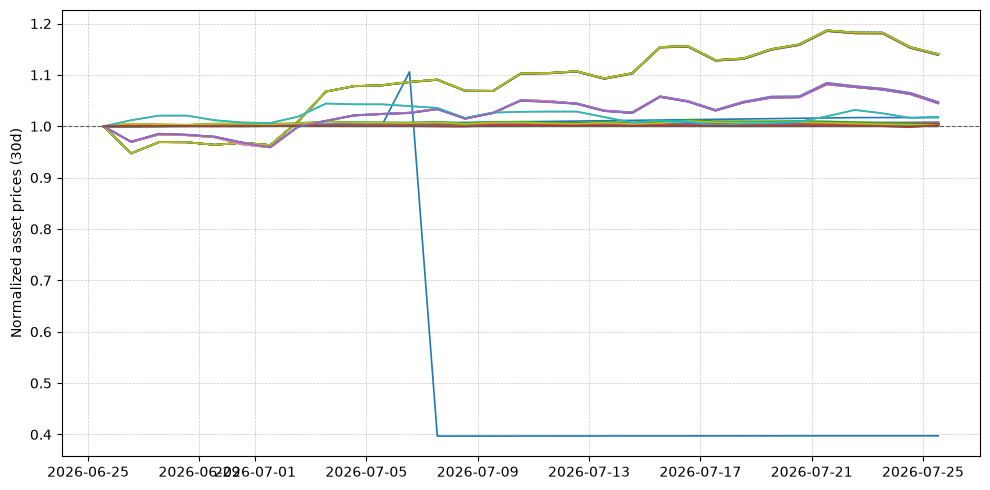

In [43]:
normalized = prices / prices.iloc[0]

fig, ax = plt.subplots(figsize=(10, 5))
for col in normalized.columns:
    ax.plot(normalized.index, normalized[col], linewidth=1.2, label=col)
ax.axhline(1.0, color=MUTED, linewidth=0.8, linestyle="--")
ax.set_ylabel(f"Normalized asset prices ({LOOKBACK_DAYS}d)")
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
fig.tight_layout()
plt.show()

## 4. Cross-sectional summary stats

Total return (price path), mean / vol of **excess** returns, and a rough Sharpe on the excess series.

In [15]:
stats_rows = []
for col in excess_returns.columns:
    r = excess_returns[col].dropna()
    if len(r) < 2:
        continue
    total_ret = float(prices[col].iloc[-1] / prices[col].iloc[0] - 1.0)
    n_days = max(1, (prices.index[-1] - prices.index[0]).days)
    period_rfr = (1.0 + rfr_annual) ** (n_days / 365.0) - 1.0
    total_excess = total_ret - period_rfr
    mu = float(r.mean())
    vol = float(r.std())
    stats_rows.append(
        {
            "asset": col,
            "total_return": total_ret,
            "total_excess": total_excess,
            "mean_daily_excess": mu,
            "daily_vol": vol,
            "ann_vol": vol * np.sqrt(365),
            "sharpe_daily": mu / vol if vol > 0 else float("nan"),
            "n_obs": len(r),
        }
    )

stats = pd.DataFrame(stats_rows).sort_values("sharpe_daily", ascending=False)
stats


,asset,total_return,total_excess,mean_daily_excess,daily_vol,ann_vol,sharpe_daily,n_obs
44,Fluid Lite USD Vault,0.006806,0.003498,0.000116,7.352396e-06,0.000140,15.782530,30
73,UltraYield USD,0.007213,0.003905,0.000130,2.360887e-05,0.000451,5.485470,30
48,Syrup USDC,0.003975,0.000667,0.000022,4.910640e-06,0.000094,4.513535,30
75,kpk USDC Yield,0.004635,0.001327,0.000044,1.499889e-05,0.000287,2.938029,30
82,Steakhouse High Yield USDC,0.004108,0.000800,0.000027,1.027504e-05,0.000196,2.587083,30
...,...,...,...,...,...,...,...,...
22,USDC-1 yVault,0.002688,-0.000620,-0.000021,6.353903e-06,0.000121,-3.243571,30
52,Spark Savings USDC,0.002907,-0.000401,-0.000013,6.355124e-07,0.000012,-20.955514,30
51,Spark USDC Vault,0.002908,-0.000401,-0.000013,5.672342e-07,0.000011,-23.466869,30
16,Keyrock USDC,0.000000,-0.003308,-0.000110,0.000000e+00,0.000000,NaN,30


## 5. Excess-return distributions

Histograms of daily **excess** returns for 8 random assets (2×4 grid), plus the cross-section of window total excess returns.


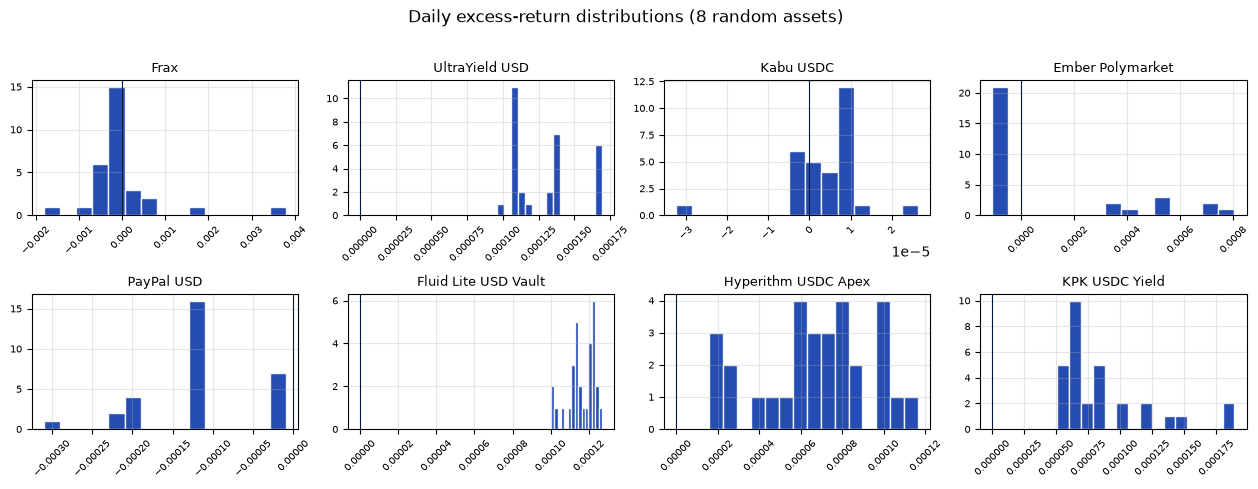

In [17]:
rng = np.random.default_rng(42)
cols = list(excess_returns.columns)
sample = list(rng.choice(cols, size=min(8, len(cols)), replace=False))

ncols = 4
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.4 * nrows), squeeze=False)

for ax, col in zip(axes.ravel(), sample, strict=False):
    r = excess_returns[col].dropna()
    ax.hist(r, bins=min(20, max(5, len(r) // 2)), color=BLUE, edgecolor="white", alpha=0.9)
    ax.axvline(0, color=NAVY, linewidth=0.8)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.tick_params(axis="x", labelrotation=45)
    ax.grid(True, alpha=0.3)

for ax in axes.ravel()[len(sample) :]:
    ax.set_visible(False)

fig.suptitle("Daily excess-return distributions (8 random assets)", y=1.01)
fig.tight_layout()
plt.show()


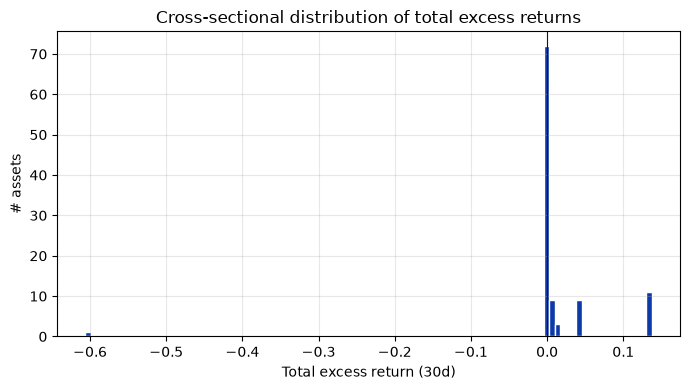

In [42]:
if stats.empty:
    print("Not enough history for a total-excess histogram.")
else:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(
        stats["total_excess"],
        bins=len(stats),
        color=BLUE,
        edgecolor="white",
    )
    ax.axvline(0, color=NAVY, linewidth=0.8)
    ax.set_xlabel(f"Total excess return ({LOOKBACK_DAYS}d)")
    ax.set_ylabel("# assets")
    ax.set_title("Cross-sectional distribution of total excess returns")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

## 6. Covariance and correlation

Pairwise structure of **excess** returns. Useful before choosing vault weights or a benchmark basket.


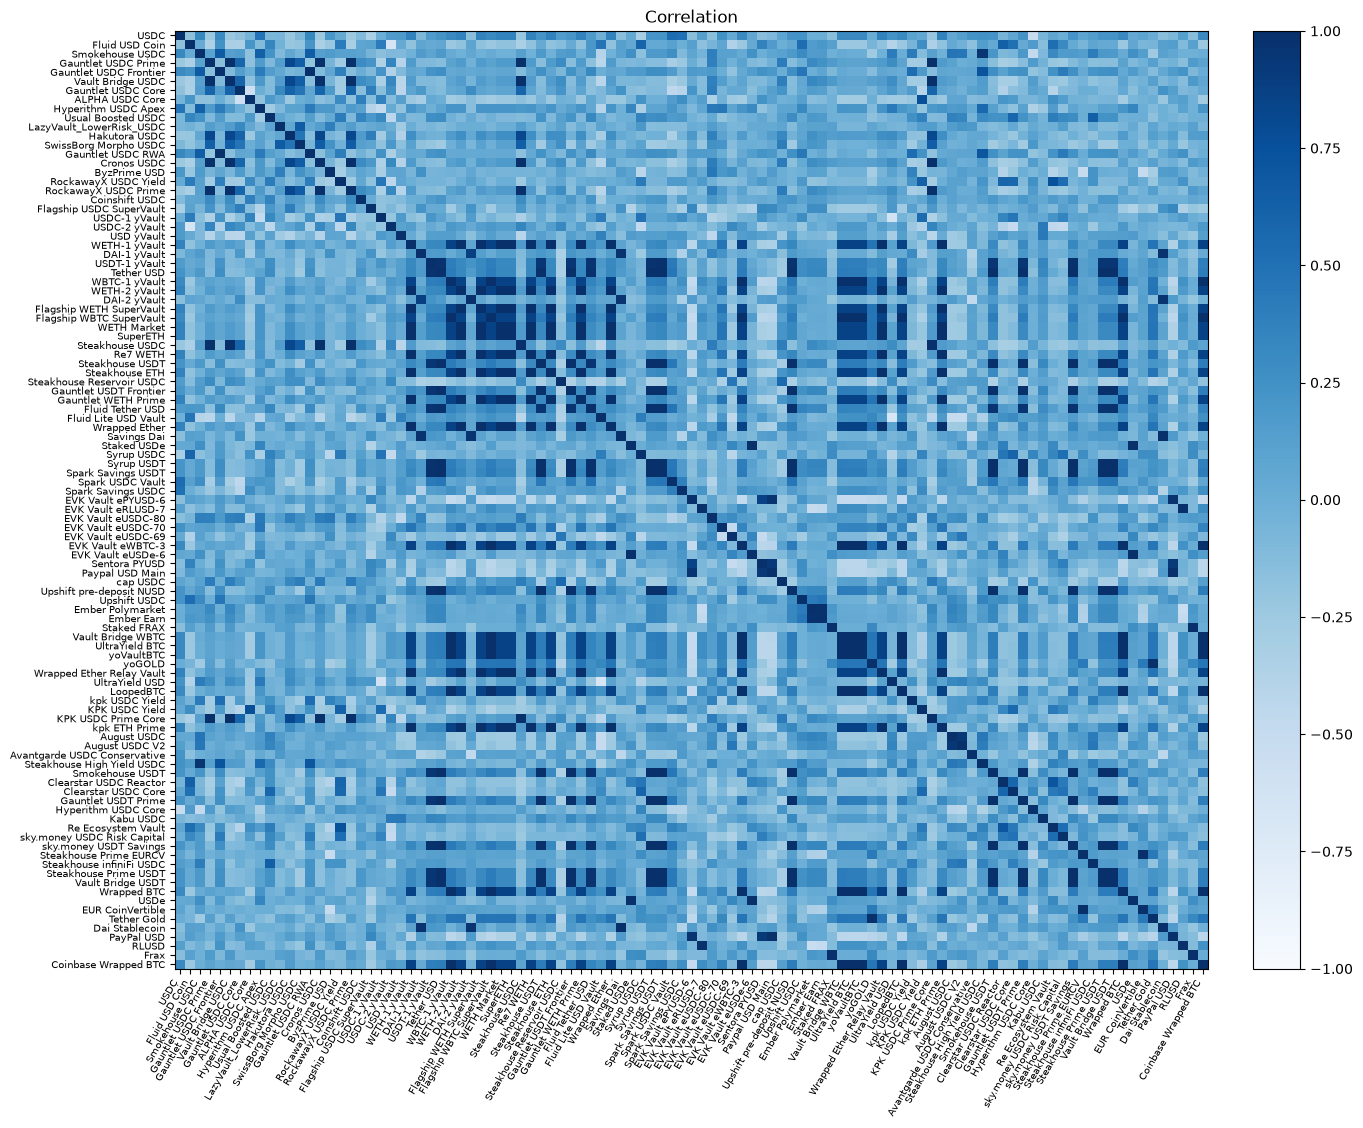

,USDC,Fluid USD Coin,Smokehouse USDC,Gauntlet USDC Prime,Gauntlet USDC Frontier,Vault Bridge USDC,Gauntlet USDC Core,ALPHA USDC Core,Hyperithm USDC Apex,Usual Boosted USDC,...,Vault Bridge USDT,Wrapped BTC,USDe,EUR CoinVertible,Tether Gold,Dai Stablecoin,PayPal USD,RLUSD,Frax,Coinbase Wrapped BTC
USDC,1.000000,-0.179591,0.327528,-0.245750,0.300682,-0.240039,-0.172765,-0.049116,0.477919,-0.082198,...,0.221003,0.310404,0.042880,0.084153,0.014541,-0.155694,-0.087952,0.129424,-0.147885,0.306597
Fluid USD Coin,-0.179591,1.000000,0.021238,-0.350806,0.244503,-0.321058,-0.330710,0.206368,-0.120116,0.341285,...,0.033388,-0.242146,0.060588,-0.070338,-0.055980,0.123924,0.134991,-0.111905,0.111298,-0.235410
Smokehouse USDC,0.327528,0.021238,1.000000,0.097697,0.669141,0.119324,0.149657,-0.176300,0.628569,0.234008,...,0.186810,0.016104,0.263442,0.139793,-0.261844,0.104996,0.061952,-0.017347,-0.019384,0.003791
Gauntlet USDC Prime,-0.245750,-0.350806,0.097697,1.000000,-0.153716,0.995649,0.592146,-0.179435,0.164706,-0.098314,...,-0.145824,0.096981,-0.104046,-0.030421,0.124156,-0.071996,-0.040037,-0.150458,0.164702,0.087711
Gauntlet USDC Frontier,0.300682,0.244503,0.669141,-0.153716,1.000000,-0.102409,0.136328,-0.001457,0.420162,0.145031,...,0.257858,0.042035,0.170932,0.024322,-0.125450,0.049209,0.168422,0.230235,-0.091709,0.014106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Dai Stablecoin,-0.155694,0.123924,0.104996,-0.071996,0.049209,-0.086082,0.236869,-0.222168,-0.021362,-0.017849,...,0.182779,-0.026251,-0.079693,0.103267,-0.122985,1.000000,0.156568,-0.070701,-0.204000,-0.019388
PayPal USD,-0.087952,0.134991,0.061952,-0.040037,0.168422,-0.012405,0.132397,0.080342,-0.080548,-0.047140,...,-0.080840,-0.433803,-0.154245,-0.304466,-0.407236,0.156568,1.000000,-0.056177,-0.134669,-0.443264
RLUSD,0.129424,-0.111905,-0.017347,-0.150458,0.230235,-0.138694,-0.096052,0.129348,0.094053,-0.101969,...,0.069571,0.247100,-0.075569,0.012386,0.119626,-0.070701,-0.056177,1.000000,-0.117627,0.243941
Frax,-0.147885,0.111298,-0.019384,0.164702,-0.091709,0.184275,-0.056835,-0.036169,-0.030060,-0.019485,...,-0.130578,0.011176,0.269122,0.123100,0.313552,-0.204000,-0.134669,-0.117627,1.000000,0.008806


In [35]:
corr = excess_returns.corr().dropna(axis=0, how="all").dropna(axis=1, how="all")

fig, ax = plt.subplots(figsize=(14, 12))

im = ax.imshow(corr, cmap="Blues", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=60, ha="right", fontsize=7)
ax.set_yticklabels(corr.columns, fontsize=7)
ax.set_title("Correlation")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Add more room for tick labels
fig.tight_layout(rect=[0, 0, 1, 0.97], pad=2.0)
plt.show()

corr


## 7. Principal component analysis

Standardize daily **excess** returns and run PCA with scikit-learn. Inspect explained variance and the first few factor loadings, a quick read on whether the universe is one-factor dominated.


In [36]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

R = excess_returns.dropna(how="any")
if R.shape[0] < 3 or R.shape[1] < 2:
    raise SystemExit("Need more overlapping excess-return observations for PCA.")

X_scaled = StandardScaler().fit_transform(R)
n_components = min(R.shape)
pca = PCA(n_components=n_components)
scores_arr = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
loadings = pd.DataFrame(
    pca.components_.T,
    index=R.columns,
    columns=[f"PC{i + 1}" for i in range(n_components)],
)
scores = pd.DataFrame(
    scores_arr,
    index=R.index,
    columns=[f"PC{i + 1}" for i in range(n_components)],
)

print("Explained variance ratio (first 5):")
print(pd.Series(explained[:5], index=[f"PC{i + 1}" for i in range(min(5, len(explained)))]))
print(f"\nCumulative (PC1–PC3): {explained[:3].sum():.1%}")


Explained variance ratio (first 5):
PC1    0.237492
PC2    0.136416
PC3    0.090443
PC4    0.061998
PC5    0.058344
dtype: float64

Cumulative (PC1–PC3): 46.4%


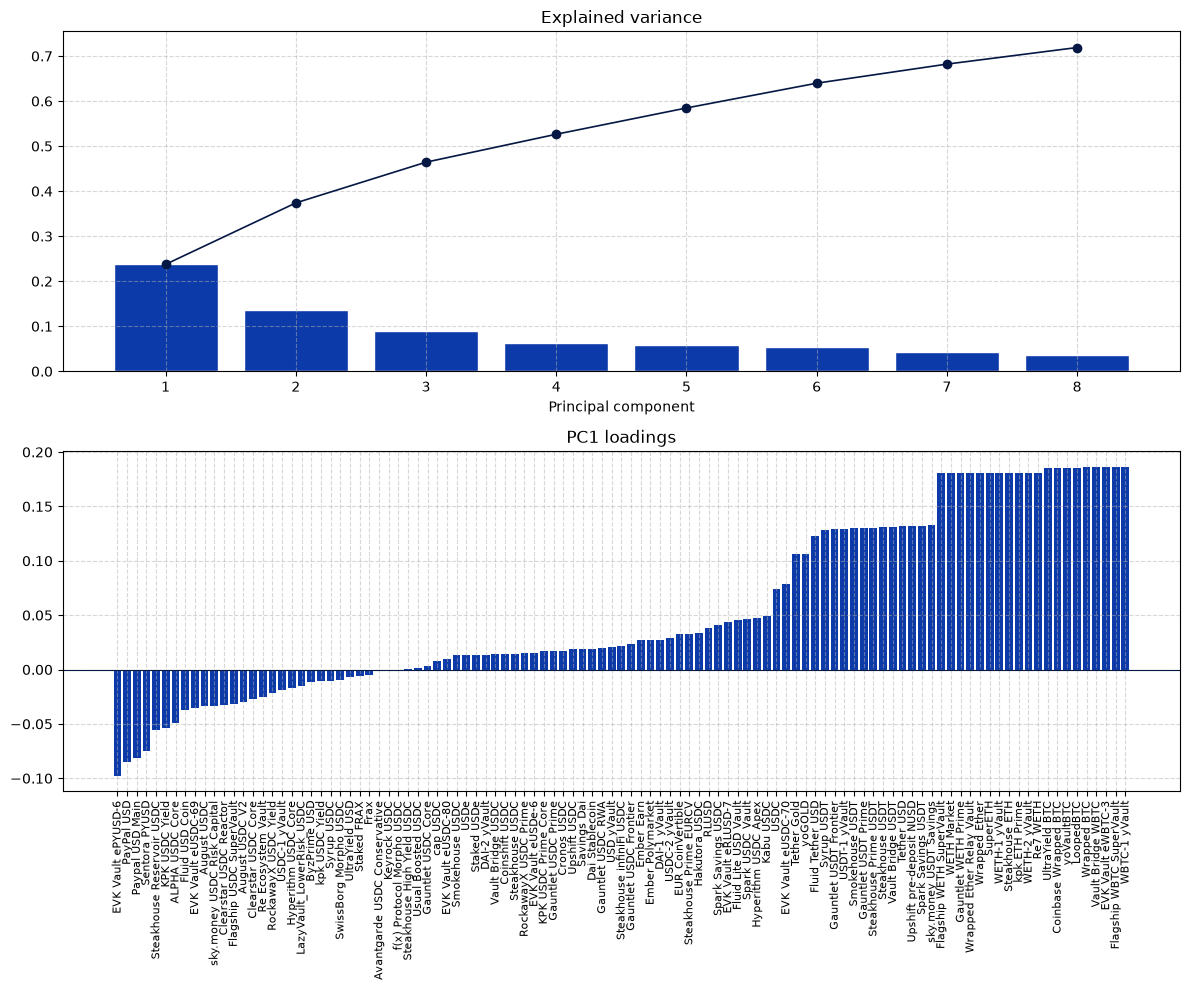

,PC1,PC2
USDC,0.073998,-0.036086
Fluid USD Coin,-0.036765,-0.118385
Smokehouse USDC,0.012991,-0.046617
Gauntlet USDC Prime,0.017022,0.182181
Gauntlet USDC Frontier,0.023906,-0.096862
Vault Bridge USDC,0.014185,0.176876
Gauntlet USDC Core,0.002979,0.121349
ALPHA USDC Core,-0.049112,-0.072450
Hyperithm USDC Apex,0.047791,0.029950
Usual Boosted USDC,0.001183,-0.106710


In [47]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

k = min(8, len(explained))
axes[0].bar(range(1, k + 1), explained[:k], color=BLUE, edgecolor="white")
axes[0].plot(
    range(1, k + 1),
    np.cumsum(explained[:k]),
    color=NAVY,
    marker="o",
    linewidth=1.2,
)
axes[0].set_xlabel("Principal component")
axes[0].set_title("Explained variance")
axes[0].set_xticks(range(1, k + 1))
axes[0].grid(True, axis='both', linestyle='--', alpha=0.5)

pc1 = loadings["PC1"].sort_values()
axes[1].bar(pc1.index, pc1.values, color=BLUE)
axes[1].axhline(0, color=NAVY, linewidth=0.8)
axes[1].set_title("PC1 loadings")
axes[1].tick_params(labelsize=8, axis='x', rotation=90)
axes[1].grid(True, axis='both', linestyle='--', alpha=0.5)

fig.tight_layout()
plt.show()

loadings[["PC1", "PC2"]].head(12)

## 8. Simple research portfolios (skfolio)

[skfolio](https://skfolio.org/) quickstart: minimum-variance `MeanRisk` on excess returns, train/test split, then out-of-sample portfolio summary. API mirrors scikit-learn.


In [ ]:
from skfolio import RiskMeasure
from skfolio.optimization import MeanRisk, ObjectiveFunction
from sklearn.model_selection import train_test_split

X = excess_returns.dropna(how="any")

vol = X.std(ddof=0)
flat = vol[vol <= 1e-10].index.tolist()
if flat:
    print(f"Dropping {len(flat)} zero-variance assets: {flat}")
    X = X.drop(columns=flat)

if X.shape[0] < 6 or X.shape[1] < 2:
    raise SystemExit("Need more overlapping excess-return observations for skfolio.")

X_train, X_test = train_test_split(X, test_size=0.33, shuffle=False)

# Minimum variance (skfolio quickstart default)
model = MeanRisk()
model.fit(X_train)
weights = pd.Series(model.weights_, index=X.columns, name="min_variance")

portfolio = model.predict(X_test)

# Maximum Sortino ratio (quickstart variant)
sortino = MeanRisk(
    objective_function=ObjectiveFunction.MAXIMIZE_RATIO,
    risk_measure=RiskMeasure.SEMI_VARIANCE,
)
sortino.fit(X_train)
sortino_port = sortino.predict(X_test)
sortino_weights = pd.Series(sortino.weights_, index=X.columns, name="max_sortino")


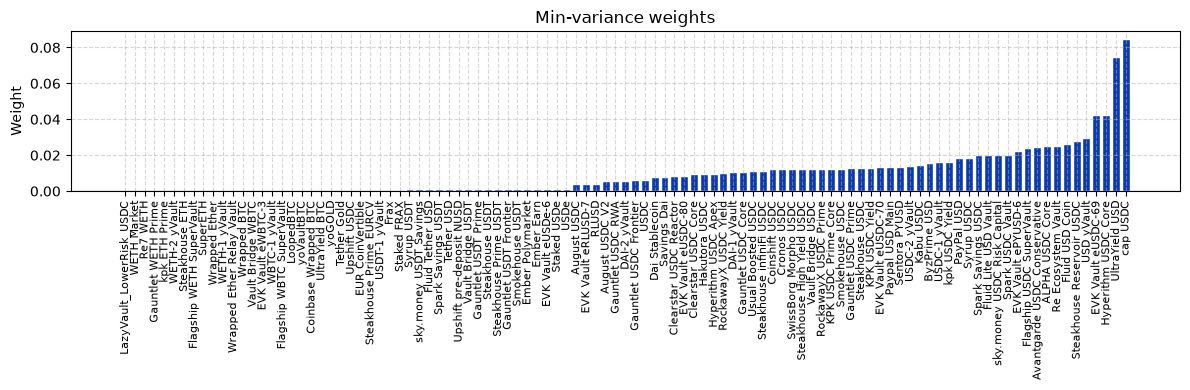

In [ ]:
w = weights.sort_values()
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(w.index, w.values, color=BLUE, edgecolor="white")
ax.axhline(0, color=NAVY, linewidth=0.8)
ax.set_title("Min-variance weights")
ax.set_ylabel("Weight")
ax.tick_params(labelsize=8, axis="x", rotation=90)
ax.grid(True, axis="both", linestyle="--", alpha=0.5)
fig.tight_layout()
plt.show()


## Next steps

- Export `excess_returns` / `stats` and feed candidate weights into an order intent (`orion submit-intent`).
- Compare a live vault's `get_intent()` and `get_portfolio_pct_tvl()` against this universe view, see `intro_analytics.ipynb`.
- Dig deeper in skfolio (HRP, CVaR, Black–Litterman): https://skfolio.org/auto_examples/index.html
